# Grids, Parametrized Grids & Torus - Embedding Visualisation

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import numpy as np
import seaborn as sns

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token
)

## Grid 4×4 (uncorrelated tokens)

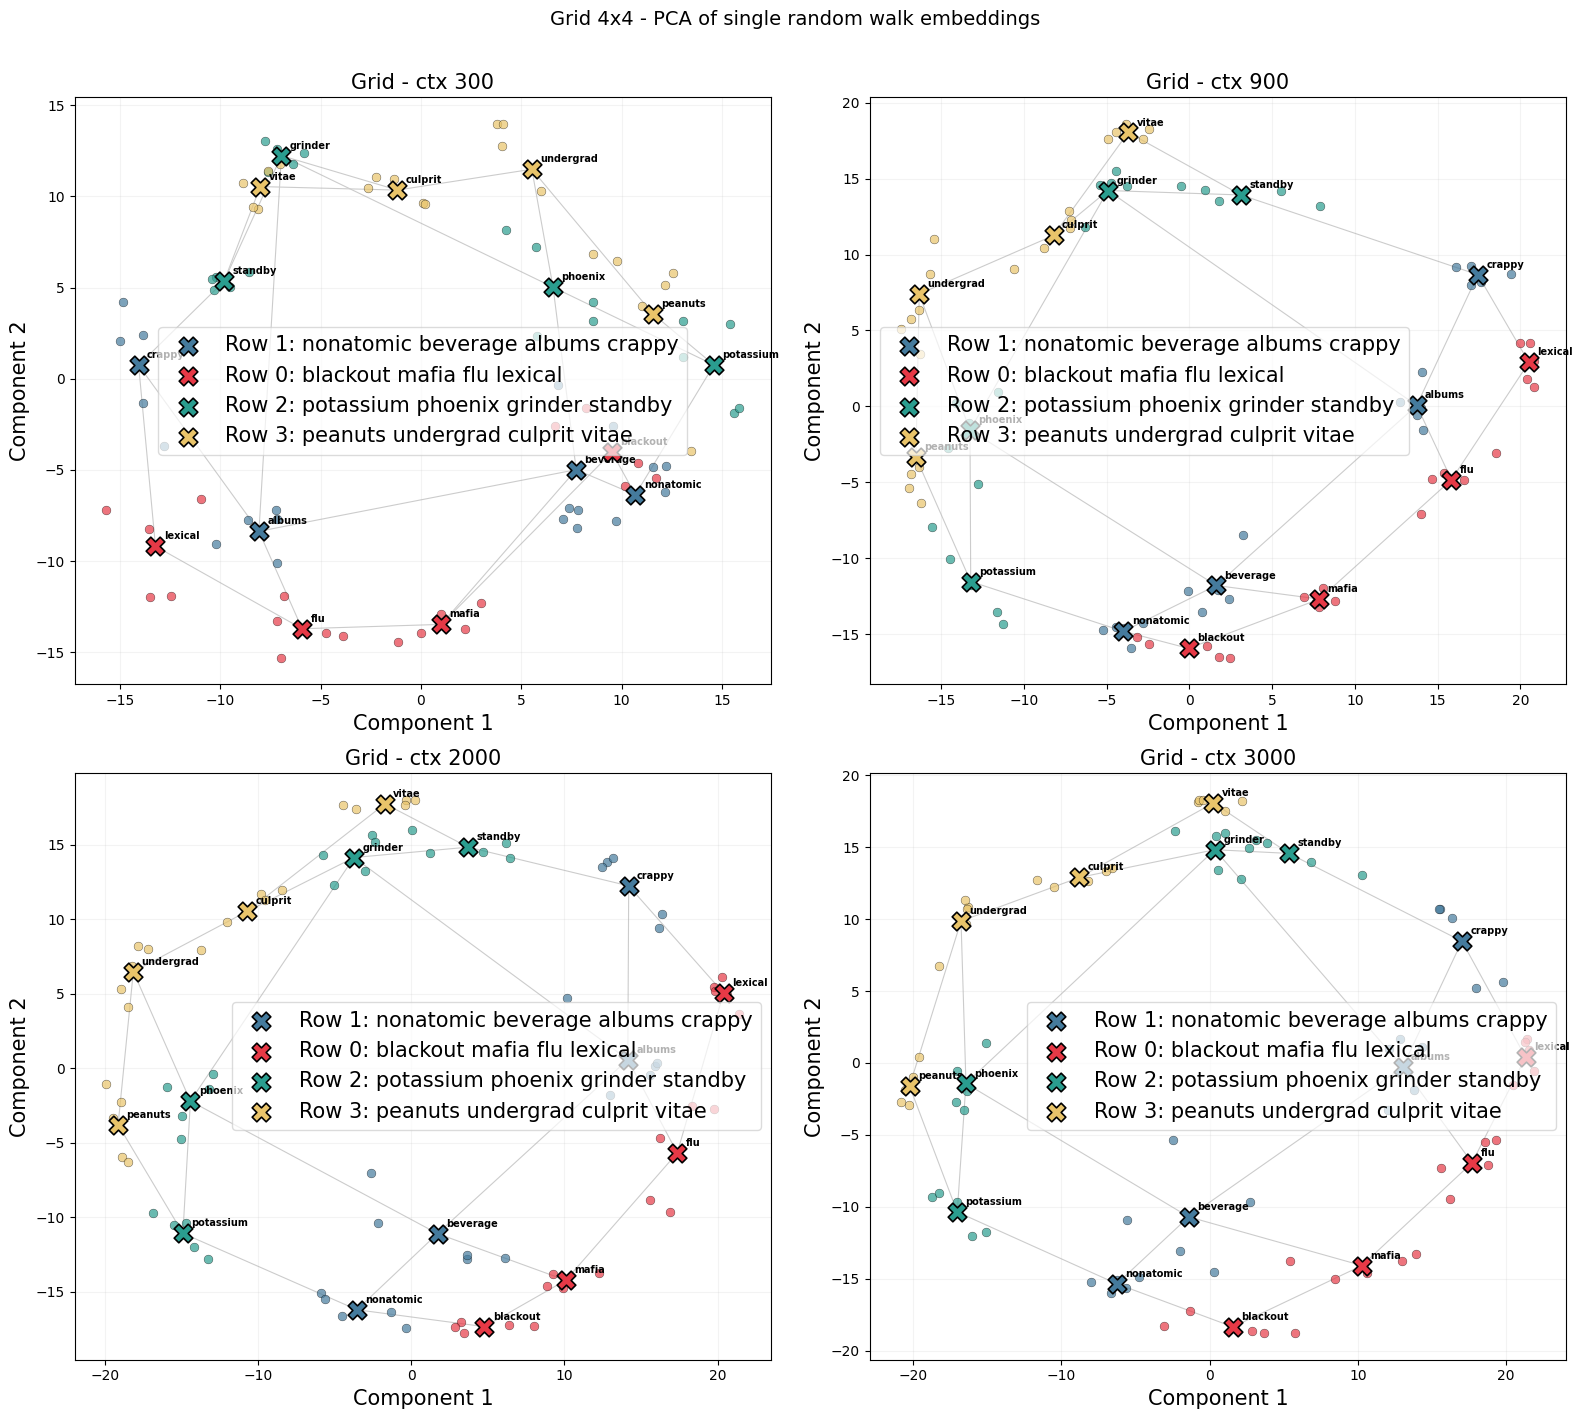

In [15]:
GRID_PATH  = Path("../data/data_3000/one_random_walk/grid_16/grid_dataset_structure.txt")
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")

EMB_DIR    = Path("../embeddings/data_3000/grid_16")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

CTX_LENS = [300, 900, 2000, 3000]
ctx=3000

for ax, wim in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path, emb_key="embeddings_last", ids_key="input_ids_last")

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, 
                                                     k=5, t_start=0, t_end=wim)

    pca = PCA(n_components=4, random_state=42)
    emb_pca = pca.fit_transform(filtered_embs)[:,:2]
    
    hp_grid.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Grid - ctx {wim}", only_centroid=False
    )

fig.suptitle("Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Tree depth=4 (uncorrelated tokens)

  [] Warning: token 'plagiarism' has only 4 occurrences in [0:300] (requested 5)
  [] Warning: token 'beverage' has only 1 occurrences in [0:300] (requested 5)
  [] Warning: token 'vitae' has only 2 occurrences in [0:300] (requested 5)
  [] Warning: token 'preserving' has only 2 occurrences in [0:300] (requested 5)
  [] Warning: token 'preserving' has only 2 occurrences in [0:900] (requested 5)


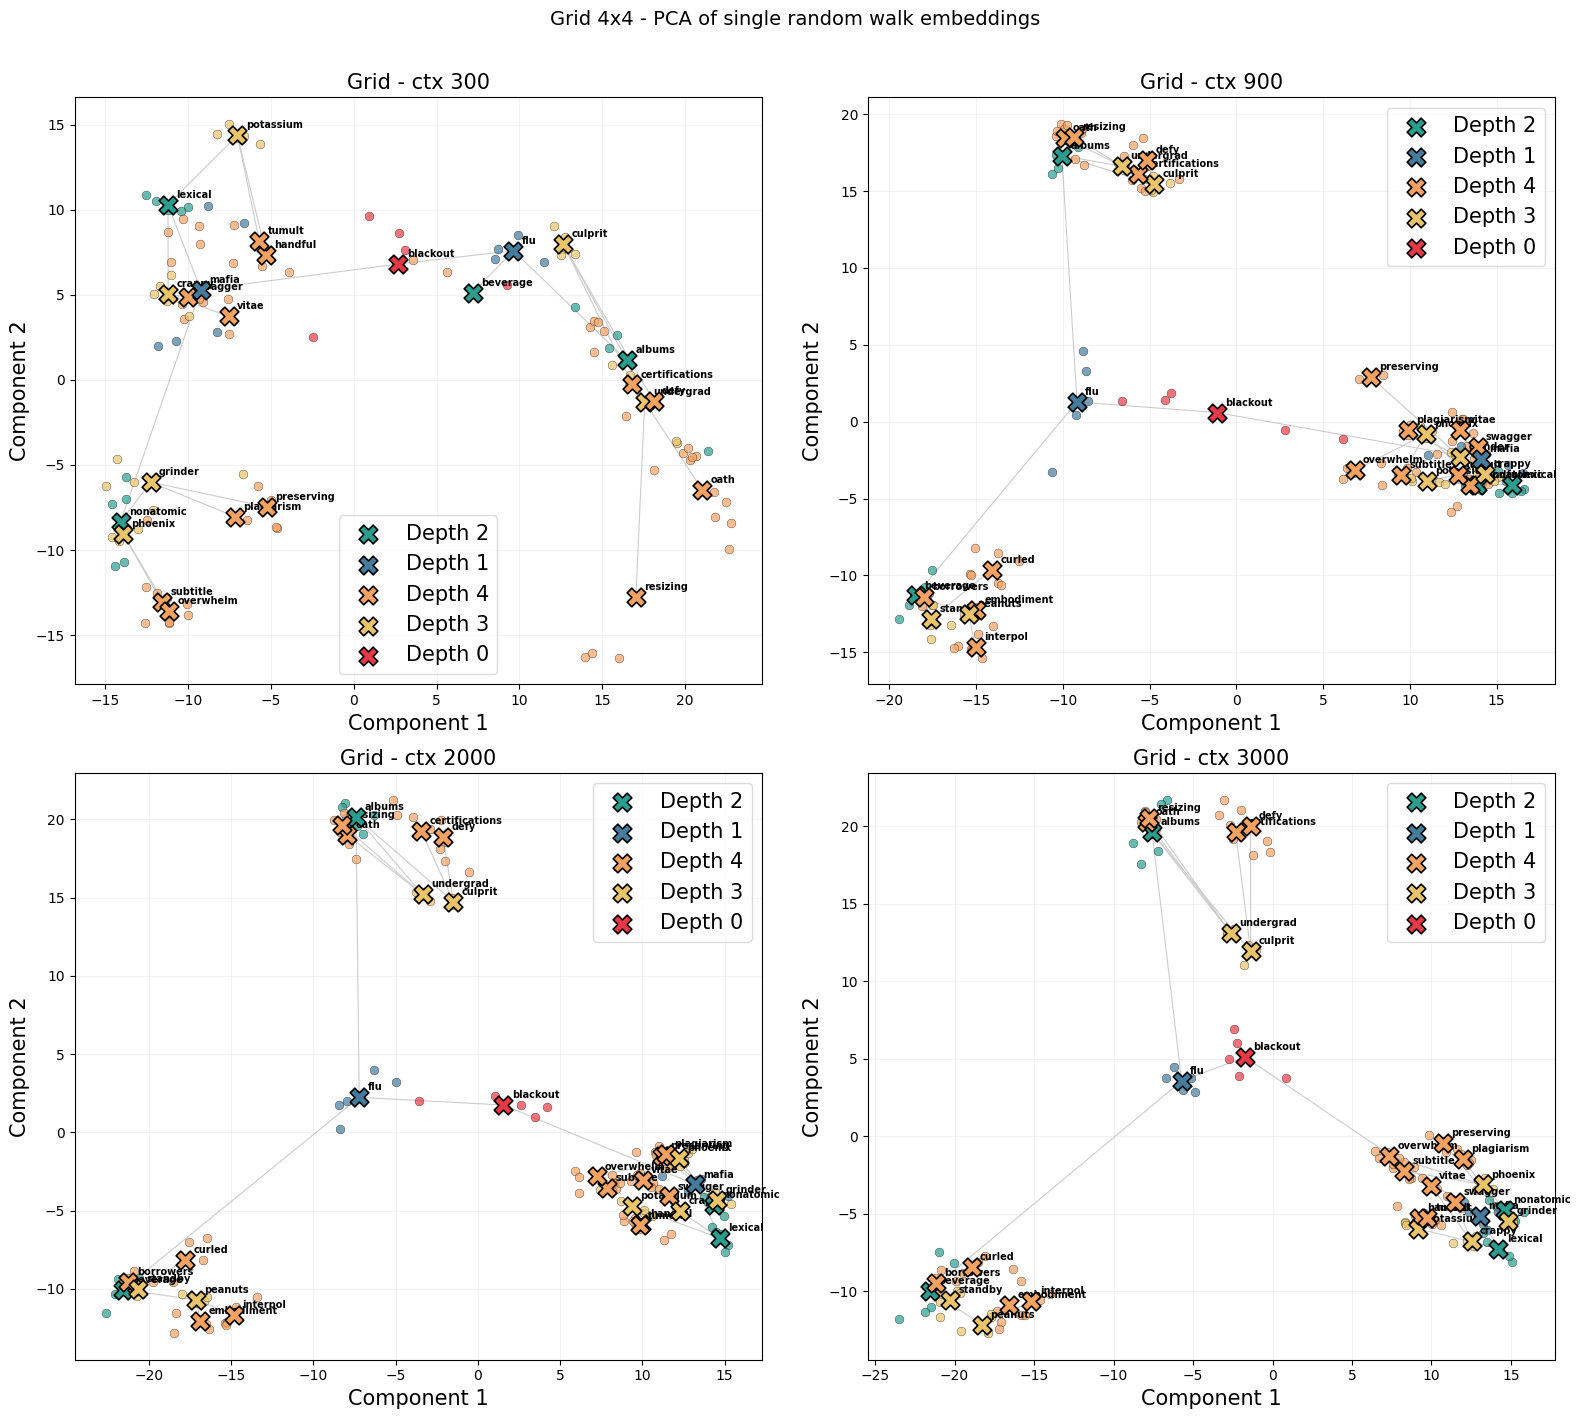

In [19]:
GRID_PATH  = Path("../data/data_3000/one_random_walk/tree_4_levels/tree_structure.txt")
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")

EMB_DIR    = Path("../embeddings/data_3000/tree_4_levels")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

CTX_LENS = [300, 900, 2000, 3000]
ctx=3000

for ax, wim in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path, emb_key="embeddings_last", ids_key="input_ids_last")

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, 
                                                     k=5, t_start=0, t_end=wim)

    pca = PCA(n_components=4, random_state=42)
    emb_pca = pca.fit_transform(filtered_embs)[:,0:2]
    
    hp_grid.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Grid - ctx {wim}", only_centroid=False
    )

fig.suptitle("Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

  [] Warning: token 'certifications' has only 3 occurrences in [0:50] (requested 5)
  [] Warning: token 'flu' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token 'albums' has only 4 occurrences in [0:50] (requested 5)
  [] Warning: token 'certifications' has only 3 occurrences in [0:100] (requested 5)
  [] Warning: token 'beverage' has only 1 occurrences in [0:100] (requested 5)
  [] Warning: token 'lexical' has only 2 occurrences in [0:100] (requested 5)
  [] Warning: token 'mafia' has only 4 occurrences in [0:100] (requested 5)
  [] Warning: token 'plagiarism' has only 4 occurrences in [0:300] (requested 5)
  [] Warning: token 'beverage' has only 1 occurrences in [0:300] (requested 5)
  [] Warning: token 'vitae' has only 2 occurrences in [0:300] (requested 5)
  [] Warning: token 'preserving' has only 2 occurrences in [0:300] (requested 5)
  [] Warning: token 'preserving' has only 2 occurrences in [0:1000] (requested 5)


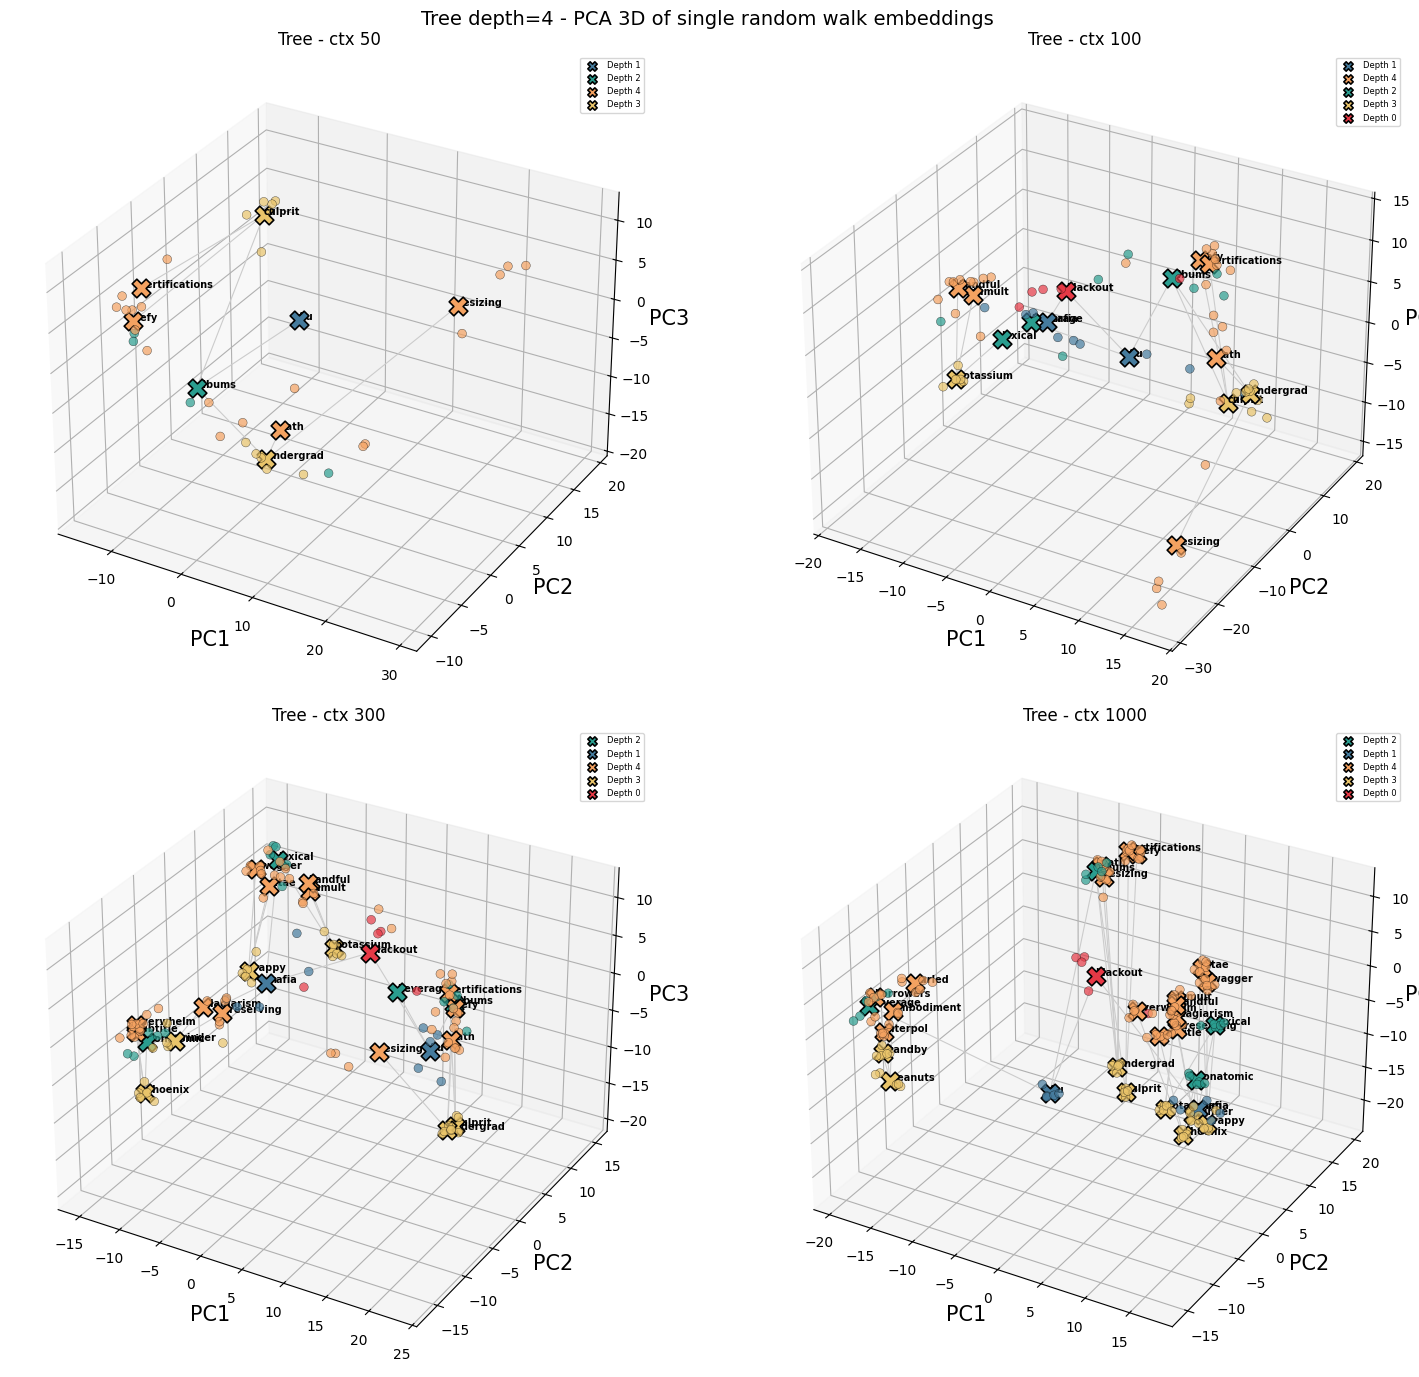

In [23]:
from mpl_toolkits.mplot3d import Axes3D

# TREE - PCA 3D
fig = plt.figure(figsize=(16, 14))
CTX_LENS = [50, 100, 300, 1000]


for i, wim in enumerate(CTX_LENS):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path, emb_key="embeddings_last", ids_key="input_ids_last")

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, 
                                                     k=5, t_start=0, t_end=wim)

    pca = PCA(n_components=4, random_state=42)
    emb_pca = pca.fit_transform(filtered_embs)[:,0:3]
    
    # For 3D plotting, you'll need to adapt the plot_reduced_emb method
    # or create a custom 3D scatter plot
    hp_grid.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Grid - ctx {wim}", only_centroid=False
    )
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'Tree - ctx {wim}')
    ax.legend(fontsize=6, markerscale=0.5)

fig.suptitle("Tree depth=4 - PCA 3D of single random walk embeddings",
             fontsize=14, y=0.98)
fig.tight_layout()
plt.show()

## pairwise distances in emb space

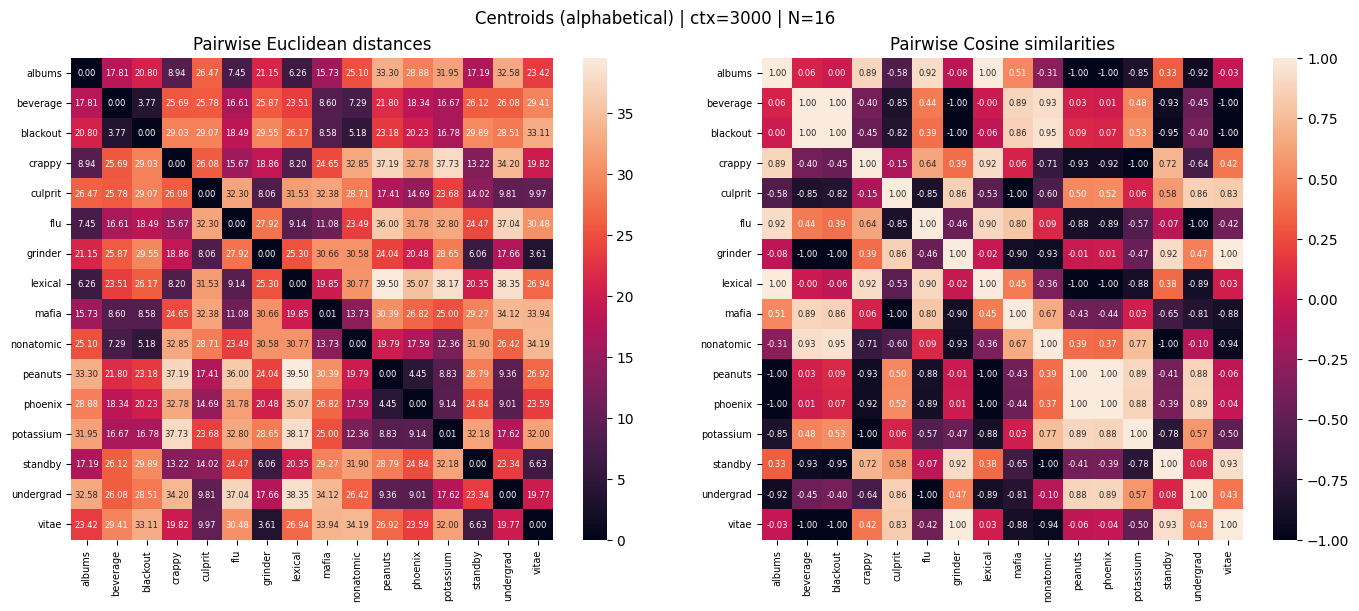

In [14]:
def pairwise_euclidean(X: np.ndarray) -> np.ndarray:
    X = X.astype(np.float32, copy=False)
    sq = np.sum(X * X, axis=1, keepdims=True)
    D2 = sq + sq.T - 2.0 * (X @ X.T)
    np.maximum(D2, 0.0, out=D2)
    return np.sqrt(D2, dtype=np.float32)

def pairwise_cosine_similarity(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = X.astype(np.float32, copy=False)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / np.maximum(norms, eps)
    return (Xn @ Xn.T).astype(np.float32)

def plot_two_annotated_heatmaps_seaborn(D_euc, S_cos, labels, suptitle="", fmt_dist=".2f", fmt_cos=".2f"):
    N = D_euc.shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    sns.heatmap(
        D_euc,
        ax=axes[0],
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt=fmt_dist,
        annot_kws={"fontsize": 6},
        cbar=True,
        square=True
    )
    axes[0].set_title("Pairwise Euclidean distances")
    axes[0].tick_params(axis="x", rotation=90, labelsize=7)
    axes[0].tick_params(axis="y", rotation=0, labelsize=7)

    sns.heatmap(
        S_cos,
        ax=axes[1],
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt=fmt_cos,
        annot_kws={"fontsize": 6},
        cbar=True,
        square=True,
        vmin=-1, vmax=1
    )
    axes[1].set_title("Pairwise Cosine similarities")
    axes[1].tick_params(axis="x", rotation=90, labelsize=7)
    axes[1].tick_params(axis="y", rotation=0, labelsize=7)

    if suptitle:
        fig.suptitle(suptitle, fontsize=12)

    plt.show()


# --- pipeline centroidi ---
win_ids, win_emb = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, k=100, title=f"ctx={ctx}")

centroid_ids, centroids = centroids_by_token(win_ids, win_emb)

# labels per ogni centroid (1 per token id)
labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]

# ordine alfabetico (case-insensitive); tie-break per stabilità: anche per id
order = np.lexsort((centroid_ids.astype(int), np.char.lower(np.array(labels, dtype=str))))
centroid_ids = centroid_ids[order]
centroids = centroids[order]
labels = [labels[i] for i in order]

pca = PCA(n_components=2, random_state=42)
centroids = pca.fit_transform(centroids)

D_euc = pairwise_euclidean(centroids)
S_cos = pairwise_cosine_similarity(centroids)

plot_two_annotated_heatmaps_seaborn(
    D_euc, S_cos,
    labels=labels,
    suptitle=f"Centroids (alphabetical) | ctx={ctx} | N={len(centroid_ids)}"
)

